# Returns of financial stocks

> You may find useful the material on [finance data sources](https://am01-sep24.netlify.app/reference/finance_data/).

We will use the `yfinance` package to download historical data of stock prices, calculate returns, and examine the distribution of returns.

We must first identify which stocks we want to download data for, and for this we must know their ticker symbol; Apple is known as AAPL, Microsoft as MSFT, McDonald's as MCD, etc. The file `nyse.csv` contains 508 stocks listed on the NYSE, their ticker `symbol`, `name`, the IPO (Initial Public Offering) year, and the sector and industry the company is in.

**Author:** Jash Damani

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np                 
import yfinance as yf              
from datetime import datetime      
import matplotlib.cm as cm         
import matplotlib.ticker as mtick  
import warnings                    
from skimpy import skim            


warnings.filterwarnings('ignore')  

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (6.75, 6.75)


In [ ]:
# Load the dataset from the relevant directory
nyse = pd.read_csv('../../data/nyse.csv')

dup_by_symbol = nyse[nyse.duplicated(subset=['symbol'], keep=False)]
print("Duplicates by symbol:")
print(dup_by_symbol)

# Check duplicates by name + ipo_year (if that grain makes sense)
dup_by_name_ipo = nyse[nyse.duplicated(subset=['name', 'ipo_year'], keep=False)]
print("\nDuplicates by name + ipo_year:")
print(dup_by_name_ipo)
# Printing out the first 10 observations
print(nyse.head(10))

# Printing out information of the dataset's variables
print("nData info: ")

nyse.info()

Duplicates by symbol:
Empty DataFrame
Columns: [symbol, name, ipo_year, sector, industry, summary_quote]
Index: []

Duplicates by name + ipo_year:
   symbol                           name  ipo_year            sector  \
22   AMOV  America Movil, S.A.B. de C.V.       NaN  Public Utilities   
23    AMX  America Movil, S.A.B. de C.V.       NaN  Public Utilities   
56    BBD              Banco Bradesco Sa       NaN           Finance   
57   BBDO              Banco Bradesco Sa       NaN           Finance   

                        industry                       summary_quote  
22  Telecommunications Equipment  https://www.nasdaq.com/symbol/amov  
23  Telecommunications Equipment   https://www.nasdaq.com/symbol/amx  
56                   Major Banks   https://www.nasdaq.com/symbol/bbd  
57                   Major Banks  https://www.nasdaq.com/symbol/bbdo  
  symbol                              name  ipo_year             sector  \
0    MMM                        3M Company       NaN        He

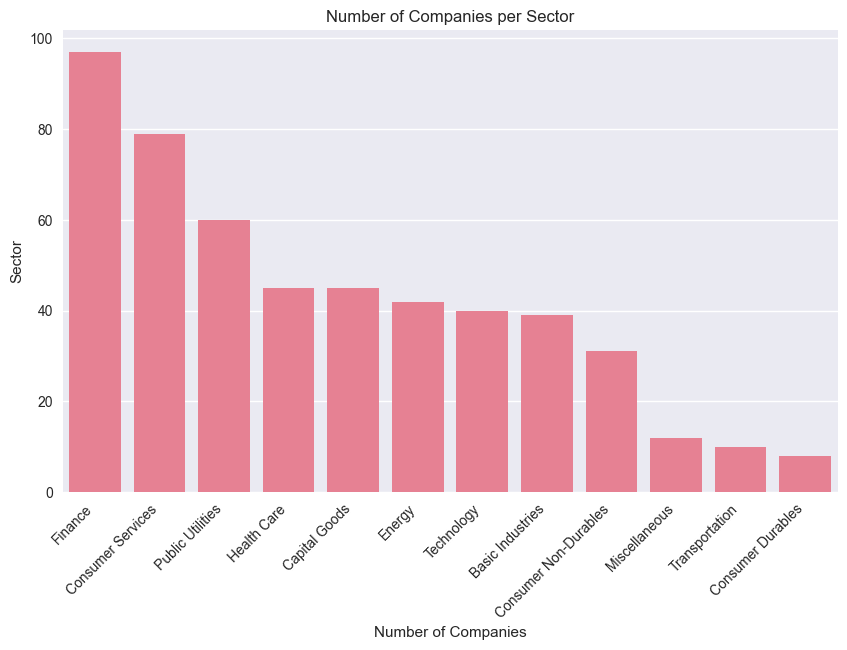

In [4]:
# Companies per sector
sector_counts = nyse['sector'].value_counts().reset_index()
sector_counts.columns = ['sector', 'num_companies']
sector_counts = sector_counts.sort_values('num_companies', ascending=False)
sector_counts

# Bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=sector_counts, x='sector', y='num_companies')
plt.xlabel('Number of Companies')
plt.ylabel('Sector')
plt.title('Number of Companies per Sector')
plt.xticks(rotation=45, ha='right')
#plt.tight_layout()
plt.show()

Next, let's choose some stocks and their ticker symbols and download some data. You **MUST** choose 6 different stocks from the ones listed below; You should, however, add `SPY` which is the SP500 ETF (Exchange Traded Fund).

In [5]:
# Download stock data

# List of stock symbols to download
my_stocks = ["BMY",  "KEYS",  "EFX",  "KMI",  "F", "HPE","SPY"]

# Dictionary to store each individual stock DataFrame
stock_data = {}

# Loop through each stock symbol
for symbol in my_stocks:
    try:
        # Download stock data with auto_adjust=False to include both 'Close' and 'Adj Close'
        stock = yf.download(
            symbol,
            start="2013-01-01",
            end="2025-08-31",
            auto_adjust=False,   # Ensures 'Adj Close' is included explicitly
            actions=True,        # Optional: includes dividends and splits if present
            progress=False
        )

        # Add stock symbol as a column to identify source
        stock['Symbol'] = symbol

        # Save stock DataFrame in dictionary
        stock_data[symbol] = stock

        # Print progress
        print(f"✅ Downloaded {symbol}: {len(stock)} rows")

    except Exception as e:
        print(f"⚠️ Error downloading {symbol}: {e}")




# Combine all data

my_stocks_df = pd.concat(stock_data.values(), ignore_index=True)


print("\nCombined data shape:", my_stocks_df.shape) # print out the data's shape (columns & rows)
print("\nData info:")
print(my_stocks_df.info()) # variable names, data types, missing values etc.

my_stocks_df.head() # summary statistics of the dataset

✅ Downloaded BMY: 3185 rows
✅ Downloaded KEYS: 2732 rows
✅ Downloaded EFX: 3185 rows
✅ Downloaded KMI: 3185 rows
✅ Downloaded F: 3185 rows
✅ Downloaded HPE: 2481 rows
✅ Downloaded SPY: 3185 rows

Combined data shape: (21138, 58)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21138 entries, 0 to 21137
Data columns (total 58 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (Adj Close, BMY)      3185 non-null   float64
 1   (Close, BMY)          3185 non-null   float64
 2   (Dividends, BMY)      3185 non-null   float64
 3   (High, BMY)           3185 non-null   float64
 4   (Low, BMY)            3185 non-null   float64
 5   (Open, BMY)           3185 non-null   float64
 6   (Stock Splits, BMY)   3185 non-null   float64
 7   (Volume, BMY)         3185 non-null   float64
 8   (Symbol, )            21138 non-null  object 
 9   (Adj Close, KEYS)     2732 non-null   float64
 10  (Close, KEYS)         2732 non-nu

Price,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume,Symbol,Adj Close,...,Volume,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,BMY,BMY,BMY,BMY,BMY,BMY,BMY,BMY,,KEYS,...,HPE,SPY,SPY,SPY,SPY,SPY,SPY,SPY,SPY,SPY
0,21.202791,32.709999,0.35,32.840000,32.500000,32.840000,0.0,12153200.0,BMY,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21.546341,33.240002,0.00,33.279999,32.619999,32.730000,0.0,10281400.0,BMY,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21.617643,33.349998,0.00,33.430000,33.090000,33.330002,0.0,8631900.0,BMY,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21.650063,33.400002,0.00,33.540001,33.209999,33.270000,0.0,6047800.0,BMY,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,21.708393,33.490002,0.00,33.660000,33.349998,33.360001,0.0,9651300.0,BMY,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Financial performance analysis depend on returns; If I buy a stock today for 100 and I sell it tomorrow for 101.75, my one-day return, assuming no transaction costs, is 1.75%. So given the adjusted closing prices, our first step is to calculate daily and monthly returns.

In [ ]:
# Calculate returns

returns_data = {}

for symbol in my_stocks:
    if symbol in stock_data:
        stock = stock_data[symbol]

        # Daily returns (log returns)
        stock['daily_returns'] = stock['Adj Close'].pct_change()

         # Monthly returns (arithmetic)
        stock['monthly_returns'] = stock['Adj Close'].resample('M').last().pct_change()

        # Yearly returns (arithmetic)
        stock['yearly_returns'] = stock['Adj Close'].resample('Y').last().pct_change()

        returns_data[symbol] = stock

print("Returns calculated for all stocks")

Returns calculated for all stocks


Table to summarise monthly returns for each of the stocks and `SPY`; min, max, median, mean, SD.

In [7]:
# Summary of monthly returns

# empty dictionary
monthly_summary = {}

# using a for loop
for symbol in my_stocks:
    if symbol in returns_data: # check that the stock's data is in our dataframe
        monthly_returns = returns_data[symbol]['monthly_returns'].dropna() # removes na values from the monthly returns column
        monthly_summary[symbol] = {     # we add new variables containing statistical summaries for monthly returns of each stock

            'min': monthly_returns.min(),

            'max': monthly_returns.max(),

            'median': monthly_returns.median(),

            'mean': monthly_returns.mean(),

            'std': monthly_returns.std()

        }

monthly_summary_df = pd.DataFrame(monthly_summary).T.round(4)  # we store the outputs in a new dataframe; values are rounded to 4 decimal places
# Note: .T here transposes the rows as columns (the stat measures e.g. mean, median etc. become new columns)

# Printing out the dataset
print("Monthly returns summary:")
monthly_summary_df

Monthly returns summary:


,min,max,median,mean,std
BMY,-0.2329,0.1626,0.0056,0.0059,0.0751
KEYS,-0.1825,0.1923,0.0042,0.0075,0.0789
EFX,-0.2231,0.2863,0.0128,0.0126,0.0868
KMI,-0.3670,0.2084,0.0041,-0.0003,0.0802
F,-0.3060,0.2608,-0.0050,-0.0043,0.0887
HPE,-0.2325,0.3409,0.0112,0.0142,0.0957
SPY,-0.1249,0.1270,0.0174,0.0111,0.0419


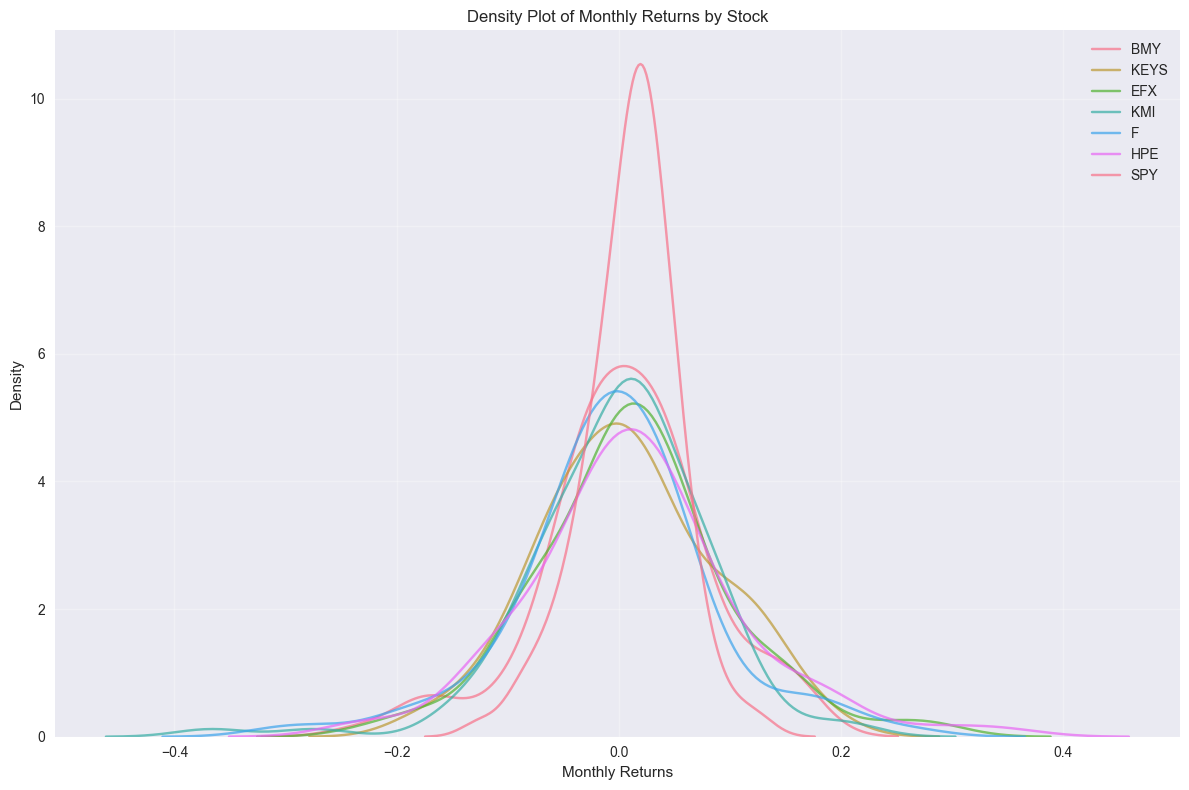

In [8]:
# Density plot of monthly returns

# setting the figure's size
plt.figure(figsize=(12, 8))

#Using a for loop for creating density plots for our stocks
for symbol in my_stocks:
    if symbol in returns_data:
        monthly_returns = returns_data[symbol]['monthly_returns'].dropna() #dropping na values
        sns.kdeplot(monthly_returns, label=symbol, alpha=0.7) # Using seaborn, we create a KDE (kernal density estimate) plot

# Plot aesthetics: labels, legends, grid etc.
plt.xlabel('Monthly Returns')
plt.ylabel('Density')
plt.title('Density Plot of Monthly Returns by Stock')
plt.legend()
plt.grid(True, alpha=0.3)

# Displaying the plot
plt.tight_layout()
plt.show()

Riskier stocks would be the ones with greater variability on their monthly returns, and hence, greater standard deviations. From our plot we can clearly see that stocks EFX (green line) and F (blue line) are the riskiest. Using the same method, we can tell that SPY is the least risky with the least variable monthly returns.

Finally, making a plot that shows the expected monthly return (mean) of a stock on the Y axis and the risk (standard deviation) in the X-axis.

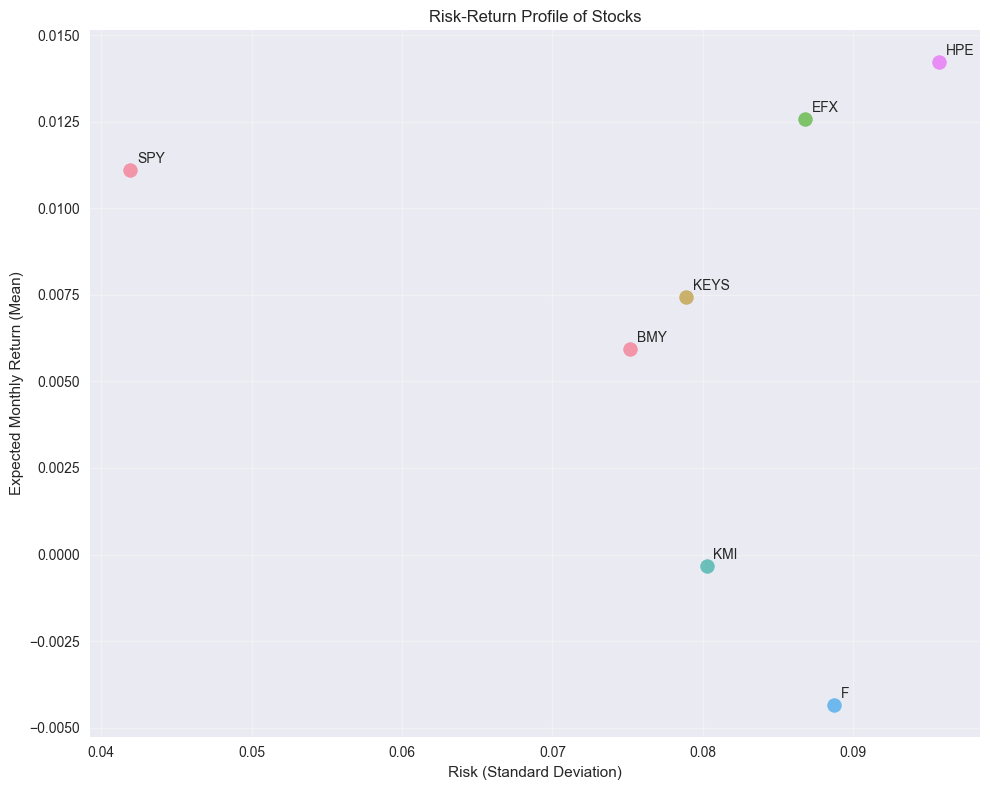

In [9]:
# Risk-return plot

# Setting the figure size
plt.figure(figsize=(10, 8))

# Using a for loop to create a scatterplot
for symbol in my_stocks:
    if symbol in monthly_summary:
        risk = monthly_summary[symbol]['std']
        return_val = monthly_summary[symbol]['mean']
        plt.scatter(risk, return_val, s=100, alpha=0.7) # s is used to set the point size
        plt.annotate(symbol, (risk, return_val), xytext=(5, 5), textcoords='offset points') # labelling the data points

# Plot Aesthetics
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Monthly Return (Mean)')
plt.title('Risk-Return Profile of Stocks')
plt.grid(True, alpha=0.3)

# Displaying the plot
plt.tight_layout()
plt.show()

It can be observed that stock "F", although riskier than stock "KMI", have a lower expected monthly returns than "KMI". From this plot we can infer that high risk is not adequate indicator to decide wether a stock has high returns or not. While the variance can tell us about a stock's risk, the sample mean can tell us more about a stock's expected return. The two need to be viewed together, not seperately, to give us a comprehensive profile of the stock.